In [1]:
# Tratamiento de datos
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd

# Gráficos
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt

# Preprocesado y modelado
# ------------------------------------------------------------------------------
#from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [2]:
url = 'https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/housingBOSTON-2.csv'
df = pd.read_csv(url,delimiter=',')

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns = "MEDV"),
                                        df['MEDV'],
                                        random_state = 123,test_size=0.2
                                    )

In [10]:
X_train.shape,X_test.shape

((404, 13), (102, 13))

In [11]:
# Creación del modelo
# ------------------------------------------------------------------------------
modelo = DecisionTreeRegressor(
            max_depth         = 4,
            random_state      = 123
          )

# Entrenamiento del modelo
# ------------------------------------------------------------------------------
modelo.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=123)

Profundidad del árbol: 4
Número de nodos terminales: 14


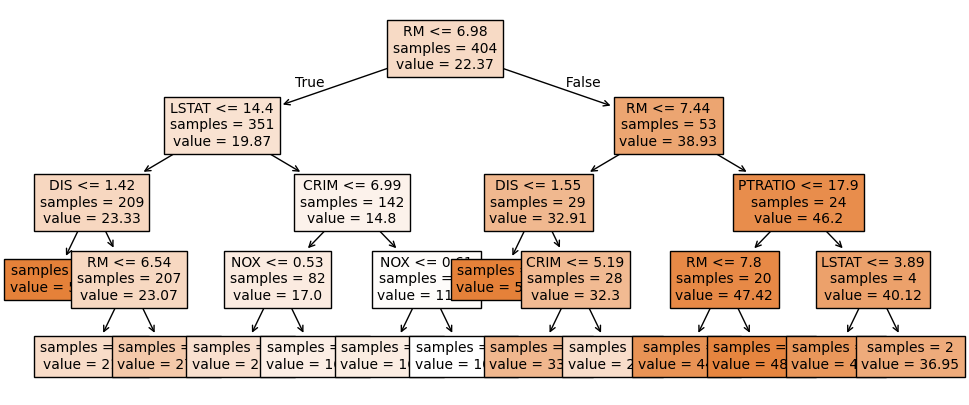

In [16]:
# Estructura del árbol creado
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

print(f"Profundidad del árbol: {modelo.get_depth()}")
print(f"Número de nodos terminales: {modelo.get_n_leaves()}")
plot = plot_tree(
            decision_tree = modelo,
            feature_names = df.drop(columns = "MEDV").columns,
            class_names   = ['MEDV'],
            filled        = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

In [17]:
texto_modelo = export_text(
                    decision_tree = modelo,
                    feature_names = list(df.drop(columns = "MEDV").columns)
               )
print(texto_modelo)

|--- RM <= 6.98
|   |--- LSTAT <= 14.40
|   |   |--- DIS <= 1.42
|   |   |   |--- value: [50.00]
|   |   |--- DIS >  1.42
|   |   |   |--- RM <= 6.54
|   |   |   |   |--- value: [21.62]
|   |   |   |--- RM >  6.54
|   |   |   |   |--- value: [27.61]
|   |--- LSTAT >  14.40
|   |   |--- CRIM <= 6.99
|   |   |   |--- NOX <= 0.53
|   |   |   |   |--- value: [20.34]
|   |   |   |--- NOX >  0.53
|   |   |   |   |--- value: [16.06]
|   |   |--- CRIM >  6.99
|   |   |   |--- NOX <= 0.61
|   |   |   |   |--- value: [16.57]
|   |   |   |--- NOX >  0.61
|   |   |   |   |--- value: [10.82]
|--- RM >  6.98
|   |--- RM <= 7.44
|   |   |--- DIS <= 1.55
|   |   |   |--- value: [50.00]
|   |   |--- DIS >  1.55
|   |   |   |--- CRIM <= 5.19
|   |   |   |   |--- value: [33.14]
|   |   |   |--- CRIM >  5.19
|   |   |   |   |--- value: [21.40]
|   |--- RM >  7.44
|   |   |--- PTRATIO <= 17.90
|   |   |   |--- RM <= 7.80
|   |   |   |   |--- value: [44.38]
|   |   |   |--- RM >  7.80
|   |   |   |   |--- v

In [18]:
y_pred = modelo.predict(X_test)

In [ ]:
# Error de test del modelo inicia
#-------------------------------------------------------------------------------


In [19]:
print("valor real --- valor de predicción")
for i in range(15):
  print("{:.2f}           {:.2f}".format(y_test.iloc[i],y_pred[i]))

valor real --- valor de predicción
15.00           50.00
26.60           27.61
45.40           48.72
20.80           21.62
34.90           27.61
21.90           36.95
28.70           21.62
7.20           10.82
20.00           20.34
32.20           33.14
24.10           21.62
18.50           21.62
13.50           16.06
27.00           21.62
23.10           16.06


In [ ]:
# probar con datos nuevos para ver que valor predice el modelo




In [20]:
newDATA=df[['RM','LSTAT','DIS','CRIM']]
newDATA.head()

,RM,LSTAT,DIS,CRIM
0,6.575,4.98,4.0900,0.00632
1,6.421,9.14,4.9671,0.02731
2,7.185,4.03,4.9671,0.02729
3,6.998,2.94,6.0622,0.03237
4,7.147,5.33,6.0622,0.06905


In [21]:
newDATA.shape

(506, 4)

In [ ]:
#DEBEN IMPLEMENTAR CON LAS 4 VARIABLES DE ENTRADA

In [22]:
X_train, X_test, y_train, y_test = train_test_split(newDATA,df['MEDV'],
                                        random_state = 123,test_size=0.2
                                    )

In [23]:
X_train.shape,X_test.shape

((404, 4), (102, 4))